# Data Inventory & Exploration

## 📖 Summary

This notebook systematically explores all data files in the `backend/data/` folder to understand what we have, identify duplicates, and inform reorganization decisions. Focus is on GeoPackages and their layer structure.

## 🎯 Objectives

1. **Inventory all GeoPackages** - What files exist and how large are they?
2. **Inspect layer structure** - What layers are in each file?
3. **Identify duplicates** - Same layers across multiple files?
4. **Check data quality** - Feature counts, CRS consistency, completeness
5. **Generate recommendations** - Which files to keep, merge, archive, or delete

## 📊 Output

- Complete inventory CSV
- Duplicate layer report
- Reorganization recommendations
- Visual file size breakdown

---

## 1. Setup

In [1]:
# Imports
import sys
sys.path.insert(0, ".")
sys.path.append("..")

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sqlite3
from datetime import datetime
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

print("✅ Imports successful!")

✅ Imports successful!


/Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Import paths
import src.paths as PATHS

In [3]:
# Configuration
DATA_DIR = PATHS.DATA_DIR
OUTPUT_DIR = DATA_DIR / "_inventory_reports"
OUTPUT_DIR.mkdir(exist_ok=True)

# Exclusions
EXCLUDE_PATTERNS = [
    '*.parquet',
    '*.png', 
    '*.jpg',
    '*.csv',
    'timeseries',  # Folder
    '.ipynb_checkpoints'
]

print(f"📂 Data directory: {DATA_DIR}")
print(f"📁 Output: {OUTPUT_DIR}")
print(f"🚫 Excluding: {', '.join(EXCLUDE_PATTERNS)}")

📂 Data directory: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data
📁 Output: /Users/admin/Documents/work/Moraine/oevererosie/wocu-oevererosie/backend/data/_inventory_reports
🚫 Excluding: *.parquet, *.png, *.jpg, *.csv, timeseries, .ipynb_checkpoints


## 2. Scan for All GeoPackages

In [4]:
print("🔍 Scanning for GeoPackages...\n")

# Find all .gpkg files
all_gpkg = list(DATA_DIR.rglob('*.gpkg'))

# Filter out excluded patterns
gpkg_files = []
for f in all_gpkg:
    # Skip if in timeseries folder
    if 'timeseries' in str(f):
        continue
    gpkg_files.append(f)

gpkg_files = sorted(gpkg_files)

print(f"✅ Found {len(gpkg_files)} GeoPackage files\n")

# Quick size overview
for f in gpkg_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    rel_path = f.relative_to(DATA_DIR)
    print(f"   {size_mb:8.1f} MB  {rel_path}")

🔍 Scanning for GeoPackages...

✅ Found 26 GeoPackage files

        1.9 MB  20260107_etienne_data/20260107_Nevengeulen_RWS_Legger.gpkg
        0.2 MB  20260107_etienne_data/Strangen_Nevengeulen_Negatief_gebufferd.gpkg
      146.0 MB  BRO_DownloadBodemkaart.gpkg
        9.2 MB  Levering_erosie_data.gpkg
        2.5 MB  Vlak_Vrijeruimte_ln.gpkg
        3.9 MB  active_water_height_stations.gpkg
        1.6 MB  all_results_20250121_v2.gpkg
      349.9 MB  all_water_stations.gpkg
       20.1 MB  all_wfs_data_batch_20260114_1245.gpkg
        2.3 MB  draft_oever_degradation_data.gpkg
        0.1 MB  erosion_border_20250129.gpkg
        1.9 MB  luke_for_feedback/phase1_2025-07-15_v3.gpkg
        5.7 MB  luke_inputs_v3.gpkg
        6.3 MB  luke_inputs_v3_w_features_20260127.gpkg
       18.9 MB  phase1_2025-08-14_v1.gpkg
       19.0 MB  phase1_2025-08-14_v1_complete_20260127.gpkg
        0.2 MB  sam/erosion_locations_sam.gpkg
       34.7 MB  sam/sam_processed.gpkg
        6.2 MB  scope_fase_2.gp

## 3. Detailed GeoPackage Inspection

In [5]:
def inspect_geopackage(gpkg_path):
    """
    Extract detailed information about a GeoPackage.
    
    Returns:
        dict with file info and list of layer details
    """
    try:
        # Connect to GeoPackage
        conn = sqlite3.connect(gpkg_path)
        cursor = conn.cursor()
        
        # Get all layers from gpkg_contents table
        cursor.execute(
            "SELECT table_name, data_type, srs_id FROM gpkg_contents ORDER BY table_name"
        )
        layers_info = cursor.fetchall()
        
        layers = []
        for table_name, data_type, srs_id in layers_info:
            # Get feature count
            try:
                cursor.execute(f"SELECT COUNT(*) FROM '{table_name}'")
                count = cursor.fetchone()[0]
            except:
                count = None
            
            # Get column info
            try:
                cursor.execute(f"PRAGMA table_info('{table_name}')")
                columns = [row[1] for row in cursor.fetchall()]
                num_columns = len(columns)
            except:
                columns = []
                num_columns = None
            
            layers.append({
                'layer_name': table_name,
                'data_type': data_type,
                'srs_id': srs_id,
                'feature_count': count,
                'num_columns': num_columns,
                'columns': columns
            })
        
        conn.close()
        
        # File metadata
        file_info = {
            'path': str(gpkg_path),
            'filename': gpkg_path.name,
            'relative_path': str(gpkg_path.relative_to(DATA_DIR)),
            'size_mb': gpkg_path.stat().st_size / (1024 * 1024),
            'modified': datetime.fromtimestamp(gpkg_path.stat().st_mtime),
            'num_layers': len(layers),
            'layers': layers
        }
        
        return file_info
        
    except Exception as e:
        return {
            'path': str(gpkg_path),
            'filename': gpkg_path.name,
            'relative_path': str(gpkg_path.relative_to(DATA_DIR)),
            'error': str(e),
            'layers': []
        }

print("✅ Inspection function defined!")

✅ Inspection function defined!


In [6]:
print("="*80)
print("INSPECTING ALL GEOPACKAGES")
print("="*80)

print(f"\n🔍 Processing {len(gpkg_files)} files...\n")

all_file_info = []

for gpkg_path in tqdm(gpkg_files, desc="Inspecting GeoPackages"):
    file_info = inspect_geopackage(gpkg_path)
    all_file_info.append(file_info)

print("\n✅ Inspection complete!")

INSPECTING ALL GEOPACKAGES

🔍 Processing 26 files...



Inspecting GeoPackages: 100%|██████████| 26/26 [00:46<00:00,  1.77s/it]


✅ Inspection complete!


## 4. File Overview & Summary

In [7]:
print("="*80)
print("FILE OVERVIEW")
print("="*80)

# Create summary DataFrame
file_summary = pd.DataFrame([{
    'filename': info['filename'],
    'size_mb': info.get('size_mb', 0),
    'num_layers': info.get('num_layers', 0),
    'modified': info.get('modified', None),
    'relative_path': info.get('relative_path', ''),
    'has_error': 'error' in info
} for info in all_file_info])

file_summary = file_summary.sort_values('size_mb', ascending=False)

print(f"\n📊 Total GeoPackages: {len(file_summary)}")
print(f"📊 Total size: {file_summary['size_mb'].sum():.1f} MB\n")

print("📋 Files by size:\n")
print(file_summary[['filename', 'size_mb', 'num_layers', 'modified']].to_string(index=False))

FILE OVERVIEW

📊 Total GeoPackages: 26
📊 Total size: 827.3 MB

📋 Files by size:

                                     filename    size_mb  num_layers                   modified
                      all_water_stations.gpkg 349.937500           1 2026-02-04 11:44:56.000000
                  BRO_DownloadBodemkaart.gpkg 145.968750          16 2026-01-14 13:44:27.000000
              wocu_output_fase2_v4_w_wfs.gpkg 139.312500           9 2026-02-16 12:48:04.716426
                           sam_processed.gpkg  34.699219           3 2025-09-16 16:03:19.000000
wocu_output_fase2_v4_w_features_20260127.gpkg  22.656250           4 2026-01-27 13:01:31.000000
                    wocu_output_fase2_v4.gpkg  22.656250           4 2026-02-04 00:38:15.241532
        all_wfs_data_batch_20260114_1245.gpkg  20.070312          46 2026-01-14 13:44:27.000000
  phase1_2025-08-14_v1_complete_20260127.gpkg  19.000000          11 2026-01-27 22:04:38.000000
                    phase1_2025-08-14_v1.gpkg  18.87109

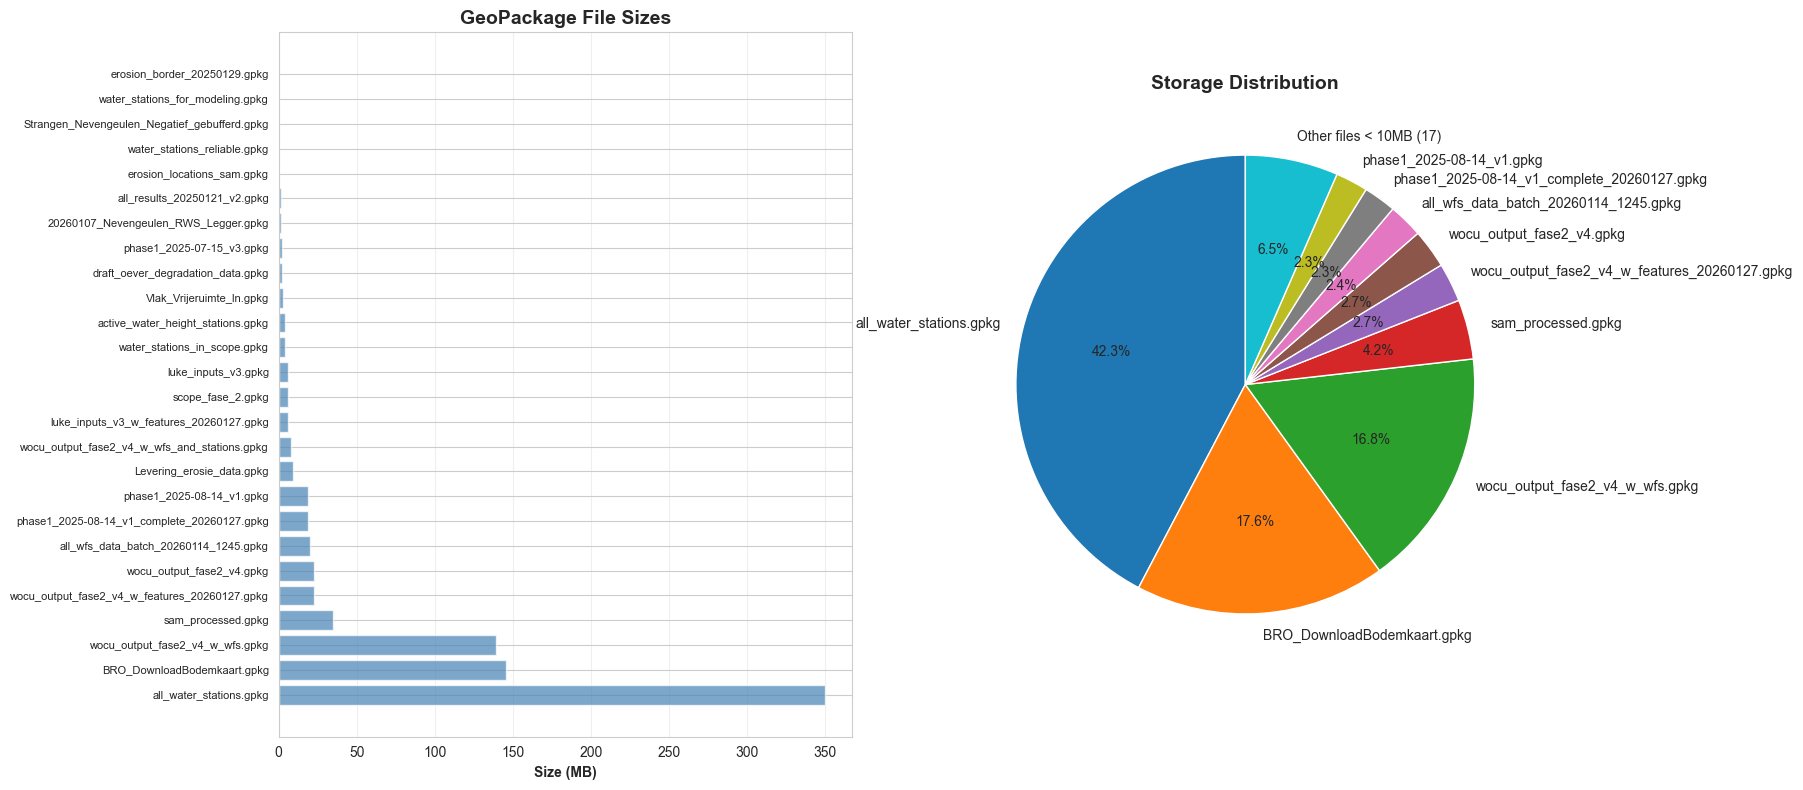

In [8]:
# Visualization: File sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Bar chart of file sizes
ax1.barh(range(len(file_summary)), file_summary['size_mb'], color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(file_summary)))
ax1.set_yticklabels(file_summary['filename'], fontsize=8)
ax1.set_xlabel('Size (MB)', fontweight='bold')
ax1.set_title('GeoPackage File Sizes', fontweight='bold', fontsize=14)
ax1.grid(axis='x', alpha=0.3)

# Pie chart of size distribution
# Group smaller files
threshold = 10  # MB
large_files = file_summary[file_summary['size_mb'] >= threshold]
small_files_total = file_summary[file_summary['size_mb'] < threshold]['size_mb'].sum()

sizes = list(large_files['size_mb'].values) + [small_files_total]
labels = list(large_files['filename'].values) + [f'Other files < {threshold}MB ({len(file_summary) - len(large_files)})']

ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Storage Distribution', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## 5. Detailed Layer Inspection

In [9]:
print("="*80)
print("DETAILED LAYER INSPECTION")
print("="*80)

# Create comprehensive layer inventory
all_layers = []

for file_info in all_file_info:
    if 'error' in file_info:
        continue
    
    for layer in file_info['layers']:
        all_layers.append({
            'file': file_info['filename'],
            'file_size_mb': file_info['size_mb'],
            'layer_name': layer['layer_name'],
            'data_type': layer['data_type'],
            'srs_id': layer['srs_id'],
            'feature_count': layer['feature_count'],
            'num_columns': layer['num_columns']
        })

layers_df = pd.DataFrame(all_layers)

print(f"\n📊 Total layers across all files: {len(layers_df)}\n")
print(f"📋 Layer count by file:\n")
print(layers_df.groupby('file')['layer_name'].count().sort_values(ascending=False))

DETAILED LAYER INSPECTION

📊 Total layers across all files: 175

📋 Layer count by file:

file
all_wfs_data_batch_20260114_1245.gpkg            46
luke_inputs_v3_w_features_20260127.gpkg          18
BRO_DownloadBodemkaart.gpkg                      16
luke_inputs_v3.gpkg                              15
phase1_2025-08-14_v1_complete_20260127.gpkg      11
wocu_output_fase2_v4_w_wfs.gpkg                   9
Levering_erosie_data.gpkg                         7
phase1_2025-08-14_v1.gpkg                         6
wocu_output_fase2_v4_w_wfs_and_stations.gpkg      5
wocu_output_fase2_v4_w_features_20260127.gpkg     4
wocu_output_fase2_v4.gpkg                         4
phase1_2025-07-15_v3.gpkg                         4
draft_oever_degradation_data.gpkg                 3
water_stations_for_modeling.gpkg                  3
Strangen_Nevengeulen_Negatief_gebufferd.gpkg      3
water_stations_reliable.gpkg                      3
sam_processed.gpkg                                3
all_results_20250121_v

In [11]:
print("\n" + "="*80)
print("LAYER-BY-LAYER DETAILS")
print("="*80)

# Print detailed info for each file
for file_info in all_file_info:
    if 'error' in file_info:
        print(f"\n❌ {file_info['filename']}")
        print(f"   Error: {file_info['error']}\n")
        continue
    
    print(f"\n📦 {file_info['filename']}")
    print(f"   Path: {file_info['relative_path']}")
    print(f"   Size: {file_info['size_mb']:.1f} MB")
    print(f"   Modified: {file_info['modified']}")
    print(f"   Layers: {len(file_info['layers'])}\n")
    
    if file_info['layers']:
        for layer in file_info['layers']:
            srs_str = f"EPSG:{layer['srs_id']}" if layer['srs_id'] else 'N/A'
            count_str = str(layer['feature_count']) if layer['feature_count'] else 'N/A'
            cols_str = str(layer['num_columns']) if layer['num_columns'] else 'N/A'
            print(f"      • {layer['layer_name']:50s} | "
                  f"{layer['data_type']:15s} | "
                  f"{srs_str:12s} | "
                  f"{count_str:>8s} features | "
                  f"{cols_str:>3s} columns")
    
    print()


LAYER-BY-LAYER DETAILS

📦 20260107_Nevengeulen_RWS_Legger.gpkg
   Path: 20260107_etienne_data/20260107_Nevengeulen_RWS_Legger.gpkg
   Size: 1.9 MB
   Modified: 2026-01-14 02:17:22.123580
   Layers: 1

      • rws_leggernevengeul_strang_legger                  | features        | EPSG:28992   |       99 features |  39 columns


📦 Strangen_Nevengeulen_Negatief_gebufferd.gpkg
   Path: 20260107_etienne_data/Strangen_Nevengeulen_Negatief_gebufferd.gpkg
   Size: 0.2 MB
   Modified: 2026-01-14 02:17:21.945702
   Layers: 3

      • Nevengeulen_min_10meter                            | features        | EPSG:28992   |       99 features |  13 columns
      • Nevengeulen_min_20meter                            | features        | EPSG:28992   |       99 features |  13 columns
      • Nevengeulen_min_5meter                             | features        | EPSG:28992   |       99 features |  13 columns


📦 BRO_DownloadBodemkaart.gpkg
   Path: BRO_DownloadBodemkaart.gpkg
   Size: 146.0 MB
   Modified:

## 6. Identify Duplicate Layers

In [12]:
print("="*80)
print("DUPLICATE LAYER ANALYSIS")
print("="*80)

print(f"\n🔍 Looking for layers that appear in multiple files...\n")

# Group by layer name
layer_occurrences = layers_df.groupby('layer_name').agg({
    'file': lambda x: list(x),
    'feature_count': lambda x: list(x),
    'file_size_mb': 'first'
}).reset_index()

layer_occurrences['num_files'] = layer_occurrences['file'].apply(len)
duplicates = layer_occurrences[layer_occurrences['num_files'] > 1].sort_values('num_files', ascending=False)

if len(duplicates) > 0:
    print(f"⚠️  Found {len(duplicates)} layers that appear in multiple files:\n")
    
    for _, row in duplicates.iterrows():
        print(f"   📁 {row['layer_name']}:")
        print(f"      Appears in {row['num_files']} files:")
        for file, count in zip(row['file'], row['feature_count']):
            print(f"         - {file:50s} ({count if count else 'N/A':>8} features)")
        print()
else:
    print("✅ No duplicate layers found - each layer appears in only one file!\n")

DUPLICATE LAYER ANALYSIS

🔍 Looking for layers that appear in multiple files...

⚠️  Found 30 layers that appear in multiple files:

   📁 vlakken_scope:
      Appears in 11 files:
         - all_results_20250121_v2.gpkg                       (      21 features)
         - draft_oever_degradation_data.gpkg                  (      21 features)
         - phase1_2025-07-15_v3.gpkg                          (      30 features)
         - luke_inputs_v3.gpkg                                (      11 features)
         - luke_inputs_v3_w_features_20260127.gpkg            (      11 features)
         - phase1_2025-08-14_v1.gpkg                          (     233 features)
         - phase1_2025-08-14_v1_complete_20260127.gpkg        (     233 features)
         - wocu_output_fase2_v4.gpkg                          (   12130 features)
         - wocu_output_fase2_v4_w_features_20260127.gpkg      (   12130 features)
         - wocu_output_fase2_v4_w_wfs.gpkg                    (   12130 features)


## 7. Identify File Relationships

In [13]:
print("="*80)
print("FILE RELATIONSHIP ANALYSIS")
print("="*80)

print(f"\n🔍 Looking for files that might be versions of each other...\n")

# Group files by similar names (base name before version/date suffixes)
import re

def extract_base_name(filename):
    """Extract base name without version/date suffixes."""
    # Remove common patterns: _v1, _v4, _w_wfs, _20260127, etc.
    patterns = [
        r'_v\d+',
        r'_w_[a-z_]+',
        r'_\d{8}',
        r'_complete',
        r'\.gpkg$'
    ]
    base = filename
    for pattern in patterns:
        base = re.sub(pattern, '', base)
    return base.rstrip('_')

file_summary['base_name'] = file_summary['filename'].apply(extract_base_name)
file_families = file_summary.groupby('base_name').agg({
    'filename': list,
    'size_mb': list,
    'num_layers': list,
    'modified': list
}).reset_index()

file_families['num_versions'] = file_families['filename'].apply(len)
multi_version = file_families[file_families['num_versions'] > 1].sort_values('num_versions', ascending=False)

if len(multi_version) > 0:
    print(f"⚠️  Found {len(multi_version)} file families with multiple versions:\n")
    
    for _, row in multi_version.iterrows():
        print(f"   📂 {row['base_name']} ({row['num_versions']} versions):")
        for filename, size, layers, modified in zip(row['filename'], row['size_mb'], row['num_layers'], row['modified']):
            print(f"      - {filename:55s} | {size:6.1f} MB | {layers:2d} layers | {modified}")
        print()
else:
    print("✅ No version families found - all files have unique base names!\n")

FILE RELATIONSHIP ANALYSIS

🔍 Looking for files that might be versions of each other...

⚠️  Found 2 file families with multiple versions:

   📂 wocu_output_fase2 (3 versions):
      - wocu_output_fase2_v4_w_wfs.gpkg                         |  139.3 MB |  9 layers | 2026-02-16 12:48:04.716426
      - wocu_output_fase2_v4.gpkg                               |   22.7 MB |  4 layers | 2026-02-04 00:38:15.241532
      - wocu_output_fase2_v4_w_wfs_and_stations.gpkg            |    7.8 MB |  5 layers | 2026-02-04 11:46:25

   📂 phase1_2025-08-14 (2 versions):
      - phase1_2025-08-14_v1_complete_20260127.gpkg             |   19.0 MB | 11 layers | 2026-01-27 22:04:38
      - phase1_2025-08-14_v1.gpkg                               |   18.9 MB |  6 layers | 2026-01-27 19:56:29



## 8. Check CRS Consistency

In [15]:
print("="*80)
print("CRS CONSISTENCY CHECK")
print("="*80)

print(f"\n📐 Checking coordinate reference systems...\n")

# Count CRS usage
crs_counts = layers_df['srs_id'].value_counts()

print(f"📊 CRS distribution across all layers:\n")
for srs_id, count in crs_counts.items():
    srs_str = f"EPSG:{int(srs_id)}" if pd.notna(srs_id) else 'Unknown'
    print(f"   {srs_str:12s}: {count:3d} layers ({count/len(layers_df)*100:.1f}%)")

# Files with mixed CRS
print(f"\n🔍 Files with multiple CRS:\n")
for file_info in all_file_info:
    if 'error' not in file_info and file_info['layers']:
        unique_crs = set(layer['srs_id'] for layer in file_info['layers'])
        if len(unique_crs) > 1:
            print(f"   ⚠️  {file_info['filename']}:")
            for crs in unique_crs:
                layer_count = sum(1 for l in file_info['layers'] if l['srs_id'] == crs)
                print(f"      • EPSG:{crs}: {layer_count} layers")
            print()

print("\n💡 Note: EPSG:28992 is RD New (Dutch standard)")
print("   All spatial operations should use this CRS!")

CRS CONSISTENCY CHECK

📐 Checking coordinate reference systems...

📊 CRS distribution across all layers:

   EPSG:28992  : 157 layers (89.7%)
   EPSG:3857   :   2 layers (1.1%)
   EPSG:4326   :   2 layers (1.1%)

🔍 Files with multiple CRS:

   ⚠️  BRO_DownloadBodemkaart.gpkg:
      • EPSG:28992: 2 layers
      • EPSG:None: 14 layers

   ⚠️  Levering_erosie_data.gpkg:
      • EPSG:28992: 6 layers
      • EPSG:3857: 1 layers

   ⚠️  sam_processed.gpkg:
      • EPSG:3857: 1 layers
      • EPSG:4326: 2 layers


💡 Note: EPSG:28992 is RD New (Dutch standard)
   All spatial operations should use this CRS!


## 9. Identify Files by Purpose

In [ ]:
print("="*80)
print("FILE CATEGORIZATION")
print("="*80)

print(f"\n🏷️  Attempting to categorize files by purpose...\n")

def categorize_file(file_info):
    """Guess file purpose based on filename and layers."""
    filename = file_info['filename'].lower()
    layers = [l['layer_name'].lower() for l in file_info.get('layers', [])]
    
    # Check filename patterns
    if 'scope' in filename:
        return 'scope_regions'
    elif 'water' in filename and 'station' in filename:
        return 'water_stations'
    elif 'wfs' in filename or any('wfs' in l for l in layers):
        return 'wfs_data'
    elif 'bodem' in filename or 'soil' in filename:
        return 'soil_data'
    elif 'erosion' in filename or 'erosie' in filename:
        return 'erosion_data'
    elif 'wocu' in filename:
        return 'erosion_bundle'  # Main working files
    elif 'phase' in filename or 'luke' in filename:
        return 'legacy_or_reference'
    elif 'sam' in filename:
        return 'sam_analysis'
    elif any(name in filename for name in ['etienne', 'levering', 'vo155']):
        return 'external_delivery'
    else:
        return 'other'

file_summary['category'] = [categorize_file(info) for info in all_file_info]

# Print by category
for category in file_summary['category'].unique():
    category_files = file_summary[file_summary['category'] == category]
    total_size = category_files['size_mb'].sum()
    print(f"\n📂 {category.upper().replace('_', ' ')} ({len(category_files)} files, {total_size:.1f} MB):")
    for _, row in category_files.iterrows():
        print(f"   • {row['filename']:55s} | {row['size_mb']:6.1f} MB | {row['num_layers']:2d} layers")

## 10. Recommendations for Reorganization

In [ ]:
print("\n" + "="*80)
print("REORGANIZATION RECOMMENDATIONS")
print("="*80)

print("""
Based on the analysis, here are recommendations:

🎯 PRIORITY ACTIONS:

1. Create Folder Structure
   data/
   ├── 01_scope_fase1/       # Phase 1 reference data
   ├── 01_scope_fase2/       # Phase 2 active work
   ├── 02_raw_wfs/          # Raw WFS downloads
   ├── 03_processed/        # Filtered/clipped to scope
   ├── 04_features/         # Feature-engineered datasets
   ├── 05_model_outputs/    # For presentations/sharing
   ├── archive/             # Old versions
   └── external/            # Etienne, Luke, RWS deliveries

2. Handle Version Families
""")

# Identify version families to handle
if len(multi_version) > 0:
    print("\n   Files with multiple versions:")
    for _, row in multi_version.iterrows():
        print(f"\n   📂 {row['base_name']}:")
        
        # Find newest
        newest_idx = row['modified'].index(max(row['modified']))
        newest = row['filename'][newest_idx]
        
        print(f"      ✅ Keep: {newest} (newest, {row['modified'][newest_idx]})")
        print(f"      📦 Archive:")
        for i, filename in enumerate(row['filename']):
            if i != newest_idx:
                print(f"         - {filename}")

print("""

3. Duplicate Layers
""")

if len(duplicates) > 0:
    print(f"   Found {len(duplicates)} duplicate layers - review each to determine:")
    print(f"   • Are they truly identical? (same features)")
    print(f"   • Or different subsets/versions?")
    print(f"   • Keep the one in the most recent/comprehensive file\n")
else:
    print("   ✅ No duplicate layers found!\n")

print("""
4. External Data
   Move to external/ subfolder:
   • Levering_erosie_data.gpkg
   • VO155184_Scope_Pilot_Bankerosion_20241129/
   • 20260107_etienne_data/
   • luke_for_feedback/

5. For Tomorrow's Presentation
   Create: 05_model_outputs/predictions_for_asset_managers.gpkg
   Include ONLY:
   • Scope regions (context)
   • Erosion predictions by year
   • Key context layers (rivers, major features)
   Keep it < 50 MB for easy sharing!

💡 PHILOSOPHY SHIFT:
   Stop versioning in filenames (wocu_v4_w_wfs_and_stations_20260127)
   Start using descriptive names (erosion_segments_with_context.gpkg)
   Let Git track the versions!
""")

## 11. Save Inventory Reports

In [ ]:
print("="*80)
print("SAVING INVENTORY REPORTS")
print("="*80)

# 1. File summary
file_summary_path = OUTPUT_DIR / "geopackage_file_summary.csv"
file_summary.to_csv(file_summary_path, index=False)
print(f"\n✅ File summary: {file_summary_path}")

# 2. Layer inventory
layers_inventory_path = OUTPUT_DIR / "layer_inventory_complete.csv"
layers_df.to_csv(layers_inventory_path, index=False)
print(f"✅ Layer inventory: {layers_inventory_path}")

# 3. Duplicate layers report
if len(duplicates) > 0:
    duplicates_path = OUTPUT_DIR / "duplicate_layers_report.csv"
    duplicates.to_csv(duplicates_path, index=False)
    print(f"✅ Duplicates report: {duplicates_path}")

# 4. Version families
if len(multi_version) > 0:
    versions_path = OUTPUT_DIR / "version_families_report.csv"
    multi_version.to_csv(versions_path, index=False)
    print(f"✅ Version families: {versions_path}")

# 5. Reorganization checklist
checklist_path = OUTPUT_DIR / "reorganization_checklist.md"
with open(checklist_path, 'w') as f:
    f.write("# Data Reorganization Checklist\n\n")
    f.write(f"Generated: {datetime.now()}\n\n")
    f.write("## 📋 Tasks\n\n")
    f.write("### 1. Create Folder Structure\n")
    f.write("- [ ] Create `01_scope_fase1/`\n")
    f.write("- [ ] Create `01_scope_fase2/`\n")
    f.write("- [ ] Create `02_raw_wfs/`\n")
    f.write("- [ ] Create `03_processed/`\n")
    f.write("- [ ] Create `04_features/`\n")
    f.write("- [ ] Create `05_model_outputs/`\n")
    f.write("- [ ] Create `archive/`\n")
    f.write("- [ ] Create `external/`\n\n")
    
    f.write("### 2. Move Core Files\n")
    f.write("- [ ] `scope_fase_2.gpkg` → `01_scope_fase2/scope_regions.gpkg`\n")
    f.write("- [ ] Water stations → `01_scope_fase2/water_stations.gpkg`\n")
    f.write("- [ ] Soil data → `02_raw_wfs/soil_bodemkaart.gpkg`\n\n")
    
    if len(multi_version) > 0:
        f.write("### 3. Handle Version Families\n\n")
        for _, row in multi_version.iterrows():
            f.write(f"**{row['base_name']}** ({row['num_versions']} versions):\n\n")
            newest_idx = row['modified'].index(max(row['modified']))
            for i, filename in enumerate(row['filename']):
                if i == newest_idx:
                    f.write(f"- [ ] KEEP: `{filename}` (newest)\n")
                else:
                    f.write(f"- [ ] Archive: `{filename}`\n")
            f.write("\n")
    
    f.write("### 4. External Data\n")
    f.write("- [ ] Move Etienne's data → `external/20260107_etienne_data/`\n")
    f.write("- [ ] Move Luke's data → `external/luke_for_feedback/`\n")
    f.write("- [ ] Move RWS delivery → `external/VO155184_Scope_Pilot/`\n\n")
    
    f.write("### 5. Update Code\n")
    f.write("- [ ] Update paths in `src/paths.py`\n")
    f.write("- [ ] Update `DataHandler` to use new paths\n")
    f.write("- [ ] Update notebooks to use new paths\n\n")
    
    f.write("### 6. Git Commit\n")
    f.write("- [ ] Git add reorganized structure\n")
    f.write("- [ ] Commit with message: 'Reorganize data folder by processing stage'\n")

print(f"✅ Reorganization checklist: {checklist_path}")

print(f"\n📂 All reports saved to: {OUTPUT_DIR}")

## 12. Next Steps

In [ ]:
print("="*80)
print("NEXT STEPS")
print("="*80)

print("""
✅ Inventory complete! You now have:

1. Complete file and layer inventory (CSVs)
2. Duplicate analysis
3. Version family identification
4. Reorganization checklist

📋 Recommended workflow:

1. Open QGIS and explore each file individually
   • Load one GeoPackage at a time in blank project
   • Check layer contents and quality
   • Take notes on what's useful

2. Review the reports generated above
   • Use duplicate_layers_report.csv to find overlap
   • Use version_families_report.csv to decide which versions to keep

3. Tomorrow after presentation:
   • See which file structure worked best
   • Use that as template for 05_model_outputs/

4. When ready to reorganize:
   • Follow reorganization_checklist.md
   • Move files gradually (don't rush!)
   • Update code paths as you go
   • Git commit after each major change

💡 Don't try to reorganize everything today!
   Just understand what you have, then reorganize incrementally.
""")

print(f"\n📂 Reports location: {OUTPUT_DIR}")
print("="*80)